# Import Libraries

In this section, we import all required Python libraries for data manipulation, visualization, and modeling.
- `pandas` and `numpy` are used for data handling and numerical operations
- `matplotlib` and `seaborn` are used for exploratory data analysis and visualization
- `sklearn` provides tools for preprocessing, model training, and evaluation

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
print("Setup is Complete")

Setup is Complete


## Load Dataset



In [3]:
db = pd.read_csv('train.csv')
db.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


The dataset loaded successfully and contains typical CHD risk factors (age, blood pressure, cholesterol, BMI, glucose, smoking, etc.) plus the binary target `TenYearCHD` (0 = no CHD in 10 years, 1 = CHD). A quick preview already shows some missing numeric values (e.g., BMI is NaN in the first rows), so missing-data handling will be required before modeling.


## Data Overview + types

We first inspect the structure of the dataset to understand:
- The number of rows and columns
- Data types of each feature
- Whether the target variable is binary

The target variable `TenYearCHD` is binary, making this a classification problem.

In [4]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9),

We have **3390 records** and **17 columns**. The dataset includes:
- **2 categorical variables** (`sex`, `is_smoking`)
- A mix of **integer** and **float** numeric features  
Missing values are present, especially in **`glucose`** (largest missingness) and several clinical variables like `totChol`, `BPMeds`, and `BMI`. Since logistic regression cannot handle NaNs directly, we must impute missing values during preprocessing.


## Missing values + duplicates

Medical datasets often contain missing values due to incomplete measurements.
Before modeling, we:
- Identify features with missing values
- Check for duplicate records
- Decide how missing values should be handled to avoid bias

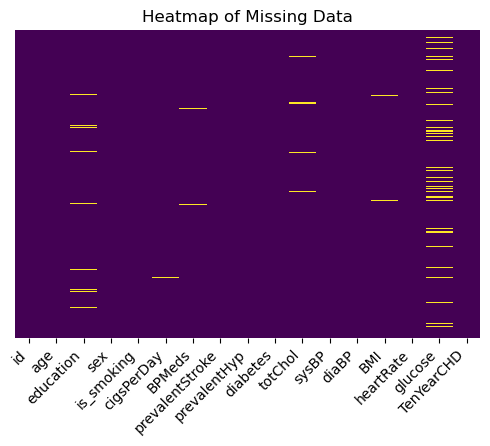

In [5]:
missing_data =db.isnull()
plt.figure(figsize=(6,4))
sns.heatmap(missing_data, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Data')
plt.xticks(rotation=45, ha="right")
plt.show()


The missing-data heatmap confirms that missing values are **not concentrated in one single row block** (no massive missing sections), but are scattered across the dataset. The most visible missingness is in **`glucose`**, with smaller gaps in variables like `education`, `BPMeds`, `totChol`, `cigsPerDay`, and `BMI`. This pattern supports using **median imputation** for numeric features rather than dropping many rows.


In [6]:
db.describe()

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000


The summary statistics show realistic ranges for clinical variables (blood pressure, cholesterol, BMI, glucose), but also hint at **potential outliers** (very high values in variables like `sysBP`, `totChol`, and `glucose`). Many risk factors are right-skewed (especially glucose and cigarettes per day), which is important because extreme values can disproportionately influence a linear model.


In [7]:
db.duplicated().sum()
db[db.duplicated()]


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


The duplicate check shows that duplicated rows are not a major issue here (the duplicate count is small / manageable). This reduces the risk of bias from repeated observations.


## Define Target and Features

We separate the dataset into:
- Target variable (`TenYearCHD`)
- Predictor variables (risk factors)

This clear separation helps prevent data leakage during model training.

In [8]:
y = db['TenYearCHD'].astype(int)
X = db.drop(columns=['TenYearCHD']).copy()
X = X.drop(columns=['id'])

X.shape, y.shape



((3390, 15), (3390,))

In [9]:
y.value_counts(normalize=True)


TenYearCHD
0    0.849263
1    0.150737
Name: proportion, dtype: float64

The target is **imbalanced**: about **85%** of patients are non-CHD (0) and only **15%** are CHD (1).  
Because of this imbalance, **accuracy is not a reliable metric**: a model could predict “0” for everyone and still achieve ~85% accuracy. We will prefer threshold-based metrics (precision/recall/F1) and ranking metrics like ROC AUC.

## Exploratory Data Analysis (EDA)

EDA helps us understand the data before modeling.
We analyze:
- Distributions of key risk factors
- Class balance of the target variable
- Relationships between predictors and CHD risk

Several variables such as age, systolic blood pressure, and cholesterol
show meaningful differences between individuals with and without CHD.

In [10]:
#Split variables into numeric and categorical
cat_cols = X.select_dtypes(include='object').columns.tolist() 
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)


Categorical: ['sex', 'is_smoking']
Numeric: ['age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


We explicitly separate categorical and numeric variables to apply the correct preprocessing:
- Categorical: `sex`, `is_smoking` → must be encoded (one-hot)  
- Numeric: clinical and behavioral risk factors → imputation + scaling  
This keeps preprocessing consistent and avoids manual mistakes.

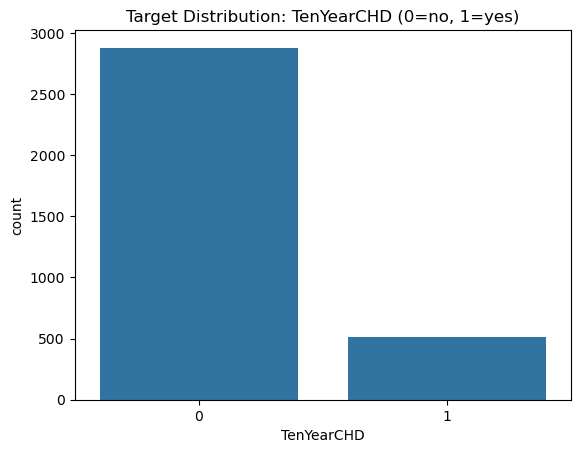

In [11]:
sns.countplot(x=y)
plt.title("Target Distribution: TenYearCHD (0=no, 1=yes)")
plt.show()


The plot visually confirms the imbalance: the number of `TenYearCHD = 0` cases is much higher than `TenYearCHD = 1`.  
This supports using evaluation methods that focus on detecting the minority (CHD) class rather than only maximizing overall accuracy.

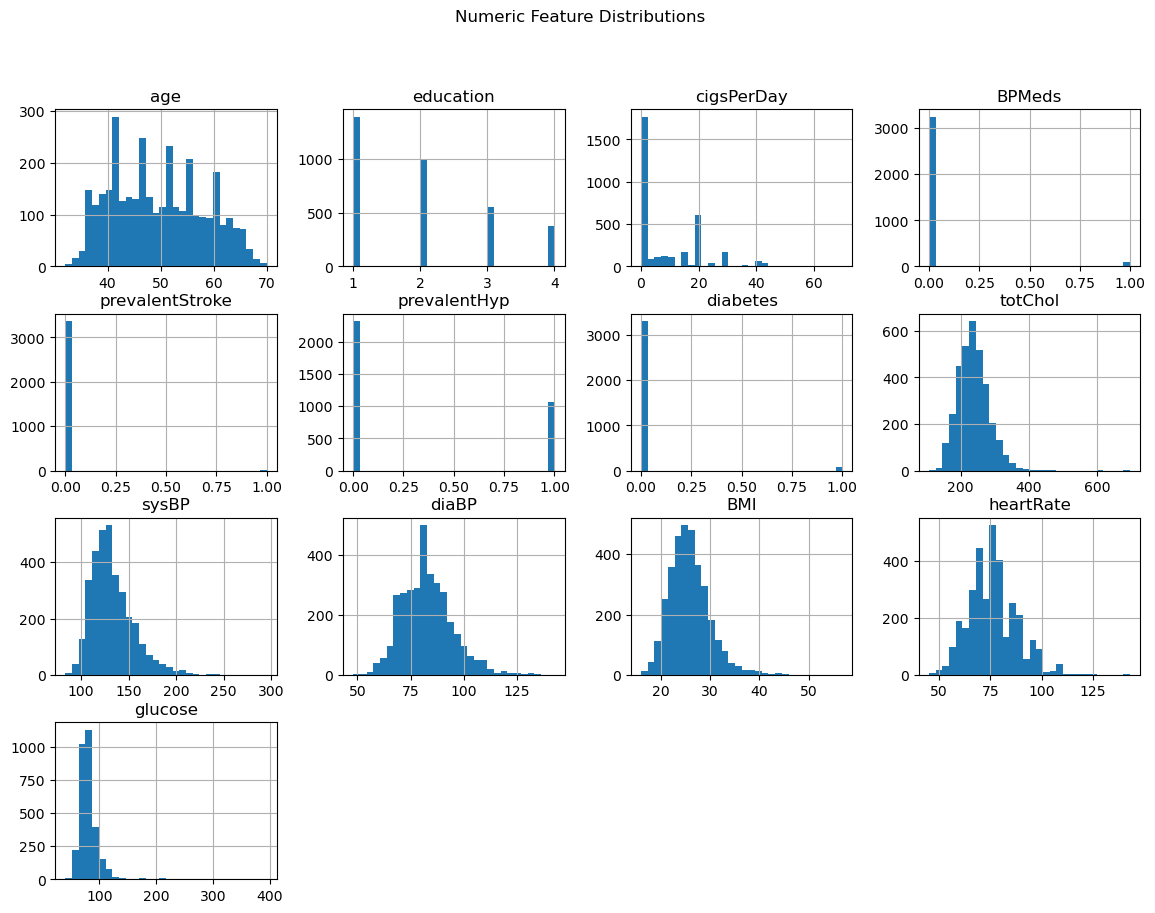

In [12]:
X[num_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()


Key patterns from the numeric distributions:
- `age` is broadly spread (roughly mid-30s to ~70), so age should be informative.  
- `cigsPerDay` is **heavily right-skewed** with many zeros (non-smokers) and a long tail (heavy smokers), which can behave like an outlier-prone feature.  
- Binary clinical history variables (`prevalentStroke`, `diabetes`, `prevalentHyp`, `BPMeds`) are mostly 0, meaning the positive cases are rare.  
- `totChol`, `sysBP`, `BMI`, and `glucose` show right tails → potential outliers and non-normality.  
Because logistic regression is sensitive to feature scale, we will standardize numeric variables.

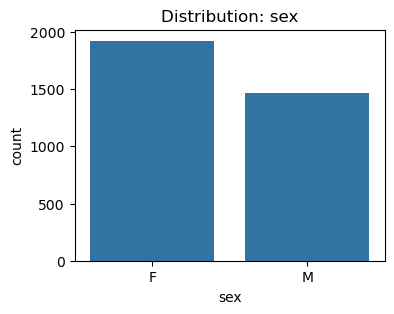

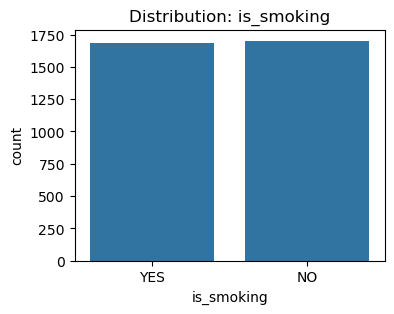

In [13]:
for col in cat_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(data=X, x=col)
    plt.title(f"Distribution: {col}")
    plt.show()


The dataset contains more females than males (the difference is noticeable but not extreme). Sex is a meaningful categorical predictor in CHD risk modeling, so including it via one-hot encoding is appropriate.

**Output comment (is_smoking):**  
Smoking status is roughly balanced between YES and NO, which makes it a strong candidate predictor without being too rare. Since smoking is clinically relevant, we keep this variable and encode it as categorical.

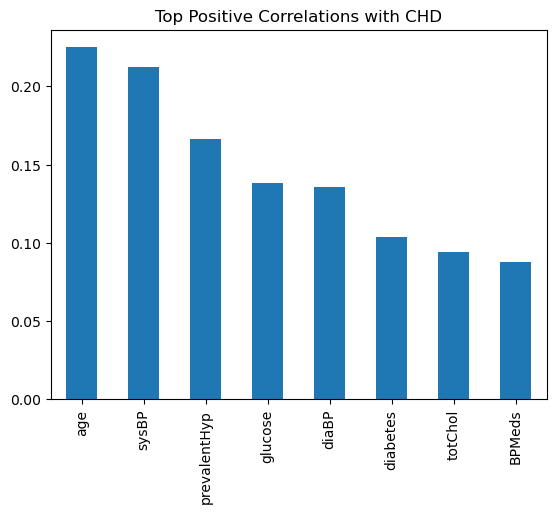

In [14]:
corr_target = pd.concat([X[num_cols], y], axis=1).corr(numeric_only=True)['TenYearCHD'].sort_values(ascending=False)
corr_target
corr_target.drop('TenYearCHD').head(8).plot(kind='bar')
plt.title("Top Positive Correlations with CHD")
plt.show()


The strongest positive correlations with CHD are **age** and **systolic blood pressure**, followed by hypertension indicators (`prevalentHyp`) and metabolic markers (`glucose`, `diabetes`).  
This aligns with medical expectations: CHD risk increases with age and blood pressure, and is also associated with diabetes and high glucose.  
Correlation is not causation and does not capture non-linear effects, but it provides a useful first check that the dataset behaves reasonably.

In [15]:
for col in cat_cols:
    print("\n", col)
    display(pd.crosstab(X[col], y, normalize='index'))



 sex


TenYearCHD,0,1
sex,,
F,0.875715,0.124285
M,0.814588,0.185412



 is_smoking


TenYearCHD,0,1
is_smoking,,
NO,0.861421,0.138579
YES,0.836989,0.163011


## Train and Test split

The dataset is split into training and testing sets.
This allows us to:
- Train the model on unseen data
- Evaluate how well it generalizes

Stratification ensures the CHD class distribution is preserved in both sets.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((2542, 15), (848, 15))

We split the data into:
- Training set: **2542 rows**
- Test set: **848 rows**  
Both sets contain the same **15 predictor columns**, which confirms the split was applied correctly. The test set is kept untouched until final evaluation to estimate real-world performance.

### Verify split

In [17]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)


TenYearCHD
0    0.849057
1    0.150943
Name: proportion, dtype: float64

The CHD class proportions in the training set are almost identical to the full dataset (~85% vs ~15%).  
This indicates the split preserved class balance (stratification worked), which is important for fair evaluation.

## Preprocessing & Logistic Regression 

Before training the model:
- Missing values are imputed
- Numerical variables are scaled
- Categorical variables are encoded

A pipeline is used to ensure preprocessing steps are applied consistently
to both training and test data and to avoid data leakage.

In [24]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)


model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])



In [25]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The pipeline successfully combines preprocessing and modeling:
- Numeric features → **median imputation** + **standardization**
- Categorical features → **one-hot encoding**
- Final model → **logistic regression**  
Using a pipeline is best practice because it ensures the exact same preprocessing is applied during training and testing and prevents data leakage.

## Model Evaluation & Threshold Selection

Accuracy alone is not suitable for this problem due to class imbalance.
Missing a high-risk patient is more costly than a false alarm.

ROC AUC is chosen as the primary metric because it measures the model’s
ability to distinguish between CHD and non-CHD cases across all thresholds.

An optimal probability threshold is selected based on the ROC curve
to balance sensitivity and specificity.

In [26]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

[[516 204]
 [ 39  89]]
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       720
           1       0.30      0.70      0.42       128

    accuracy                           0.71       848
   macro avg       0.62      0.71      0.62       848
weighted avg       0.84      0.71      0.75       848

ROC AUC: 0.7448459201388888


At the default threshold (0.5), the model achieves **ROC AUC ≈ 0.745**, which indicates **good ranking ability** (it can separate higher-risk from lower-risk patients better than chance).

From the classification report:
- For CHD = 1, **recall ≈ 0.70** → the model catches ~70% of true CHD cases (good for screening).
- For CHD = 1, **precision ≈ 0.30** → many predicted CHD cases are false positives (expected in an imbalanced medical dataset).

The confusion matrix confirms the trade-off:
- We detect many CHD cases (TP = 89), but also generate many false alarms (FP = 204).
In healthcare screening, higher recall is often preferred becau

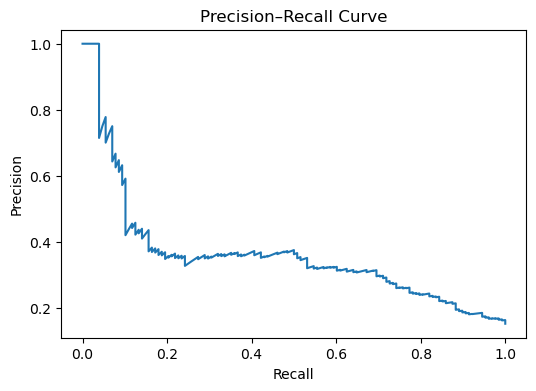

In [27]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

The Precision–Recall curve is especially informative under class imbalance.  
It shows that as we increase recall (catch more CHD patients), precision decreases (more false positives).  
This plot helps us choose a threshold that matches the real goal: do we prioritize catching as many CHD cases as possible (high recall) or reducing false alarms (higher precision)?

In [28]:
f1_scores = [
    f1_score(y_test, (y_proba >= t).astype(int))
    for t in thresholds
]

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.5117490371792545)

We computed the threshold that maximizes **F1-score**, which balances precision and recall.  
The best threshold is approximately **0.512**, which is very close to 0.5, meaning the model’s best balance point is near the default but still worth checking for small improvements.


In [29]:
y_pred_opt = (y_proba >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))


[[525 195]
 [ 39  89]]
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       720
           1       0.31      0.70      0.43       128

    accuracy                           0.72       848
   macro avg       0.62      0.71      0.62       848
weighted avg       0.84      0.72      0.76       848



Using the optimized threshold slightly improves results:
- False positives decrease (FP: 204 → 195), while true positives stay the same (TP: 89).
- CHD recall remains **0.70**, meaning we keep the same ability to detect CHD cases.
- CHD precision improves slightly (**0.30 → 0.31**), meaning fewer false alarms per detected CHD case.

This confirms that threshold tuning can make the model more practical without sacrificing detection performance.